# **AICE Associate 자격인증 <font color=red>샘플문항</font>**
### **내비게이션 주행데이터를 이용한 <span style="color:darkgreen">도착시각</span> 예측 문제**
- 내비게이션 주행데이터를 읽어들여 데이터를 분석 및 전처리한 후 머신러닝과 딥러닝으로 도착시각을 예측하고 결과를 분석하세요.
---

#### **<span style="color:red">[유의사항]</span>**
- <span style="color:darkgreen">각 문항의 답안코드는 반드시 *'# 여기에 답안코드를 작성하세요'* 로 표시된 cell에 작성해야 합니다.</span>
- <span style="color:darkgreen">제공된 시험문항 cell을 삭제하거나 답안 위치가 아닌 다른 cell에 답안코드를 작성 시 채점되지 않습니다. </span>
- 시험 중에는 상단의 '임시저장' 버튼을 클릭하여 저장을 해주시고, 답안 제출시에는 '최종제출' 버튼을 클릭해주시기 바랍니다.
- 반드시 문제에 제시된 가이드를 읽고 답안 작성하세요.
- 문제에 변수명이 제시된 경우 반드시 해당 변수명을 사용하세요.
- 자격인증 문제에 제공된 데이터는 제 3자에게 공유하거나 개인적인 용도로 사용하는 등 외부로 유출할 수 없으며 유출로 인한 책임은 응시자 본인에게 있습니다.
- <font color=blue>**오픈북 허용사이트에서만 참고 가능하며 그외 사이트 참고시 부정행위로 간주될수 있습니다.**</font>
---

**[ 데이터 컬럼 설명 (데이터 파일명: signal_data.csv) ]**

- RID                 : 경로ID
- Time_Departure      : 출발시각
- Time_Arrival        : 도착시각
- Distance            : 이동 거리, 단위 (m)
- Time_Driving        : 실주행시간(초)
- Speed_Per_Hour      : 평균시속
- Address1            : 주소1
- Address2            : 주소2
- Weekday             : Time_Departure(출발시각)의 요일
- Hour                : Time_Departure(출발시각)의 시각
- Day                 : Time_Departure(출발시각)의 날짜
- Signaltype : 경로의 신호등 갯수


<br>
<br>

### **1. Pandas는 데이터 분석을 위해 널리 사용되는 파이썬 라이브러리입니다.**
### **Pandas를 사용할 수 있도록 별칭(alias)을 pd로 해서 불러오세요.**
---

In [1]:
# 여기에 답안코드를 작성하세요.

import pandas as pd

<br>
<br>

### **2. AI 모델링을 위해 분석 및 처리할 데이터 파일을 읽어오려고 합니다.**
### **Pandas 함수로 데이터 파일을 읽어 데이터프레임 변수 df에 할당하는 코드를 작성하세요.**

* **
- 데이터프레임 변수명 : df
- 데이터 파일명 : signal_data.csv (csv 파일은 본 문제/답안지와 동일한 경로에 있습니다.)
---

In [3]:
# 여기에 답안코드를 작성하세요.

df = pd.read_csv('signal_data.csv')
df.head()

,RID,Time_Departure,Time_Arrival,Distance,Time_Driving,Speed_Per_Hour,Address1,Address2,Weekday,Hour,Day,Signaltype
0,router-84875df7fc-cmkz9-2-9617301-0,19:43:56,19:56:38.537000,3246.0,762.653992,15.322283,경기도,평택시,0,19,27,11.0
1,router-84875df7fc-scxcj-6-13366366-0,12:23:05,12:36:32.620000,3858.0,796.081970,17.446445,경기도,의정부시,4,12,24,17.0
2,router-84875df7fc-52vz8-6-62202063-0,19:10:35,19:29:07.306000,4125.0,1112.468018,13.348698,경기도,광명시,0,19,27,24.0
3,router-84875df7fc-8n4sw-5-6914479-0,11:59:58,12:10:55.999000,3748.0,651.973022,20.695335,경기도,안산시 상록구,0,11,20,19.0
4,router-84875df7fc-8n4sw-7-75115963-0,15:16:53,15:26:52.222000,3153.0,597.419006,18.999730,경기도,성남시 중원구,2,15,29,14.0


<br>
<br>

> **<span style="color:red">다음 문항을 풀기 전에 </span>아래 코드를 실행하세요.**
<small>(해결되지 않는다면 아래 Colab 한글 깨짐 현상 해결법 참고)<br>https://developnote.tistory.com/165#google_vignette </small>

In [ ]:
# (Jupyter) 시각화 한글폰트 설정을 위해 아래 코드를 실행하세요.
plt.rc('font', family='Malgun Gothic')
sns.set(font="Malgun Gothic",#"NanumGothicCoding",
        rc={"axes.unicode_minus":False}, # 마이너스 부호 깨짐 현상 해결
        style='darkgrid')

In [4]:
# (Colab) 시각화 한글폰트 설정을 위해 아래 코드를 실행하세요.
!apt -qq -y install fonts-nanum > /dev/null
!rm -rf ~/.cache/matplotlib

import matplotlib as mpl
import matplotlib.font_manager as fm
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
mpl.rcParams['font.family'] = 'NanumGothic'
mpl.rcParams['axes.unicode_minus'] = False

<br>
<br>

### **3. Address1(주소1)에 대한 분포도를 알아보려고 합니다.**
### **Address1(주소1)에 대해 countplot을 그리는 코드와 답안을 작성하세요.**

* **
- 대상 데이터프레임 : df
- Seaborn을 활용하세요.
- 첫번째, Address1(주소1)에 대해서 분포를 보여주는 countplot 그래프 그리세요.
- 두번째, Address1(주소1)에 지역명이 없는 '-' 에 해당되는 row(행)을 삭제하세요.
- 출력된 그래프를 보고 해석한 것으로 옳지 않은 선택지를 아래에서 골라 '답안03' 변수에 저장하세요.(예. 답안03 = 4)
  1. Countplot 그래프에서 Address1(주소1) 분포를 확인시 '경기도' 분포가 제일 크다.
  2. Address1(주소1) 분포를 보면 '인천광역시' 보다 '서울특별시'가 더 크다.
  3. 지역명이 없는 '-' 에 해당되는 row(행)가 2개 있다.
---

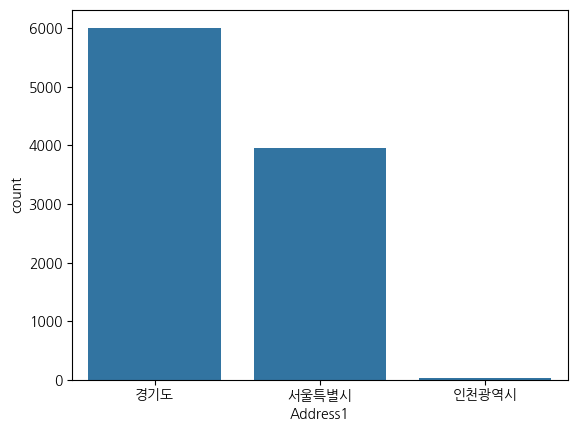

<class 'pandas.core.frame.DataFrame'>
Index: 9997 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RID             9997 non-null   object 
 1   Time_Departure  9997 non-null   object 
 2   Time_Arrival    9997 non-null   object 
 3   Distance        9995 non-null   float64
 4   Time_Driving    9997 non-null   float64
 5   Speed_Per_Hour  9997 non-null   float64
 6   Address1        9997 non-null   object 
 7   Address2        9997 non-null   object 
 8   Weekday         9997 non-null   int64  
 9   Hour            9997 non-null   int64  
 10  Day             9997 non-null   int64  
 11  Signaltype      9997 non-null   float64
dtypes: float64(4), int64(3), object(5)
memory usage: 1015.3+ KB


In [ ]:
# 여기에 답안코드를 작성하세요.
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Address1')
plt.show()

df = df[ (df['Address1'] != '-') ]
df.info()
답안04 = 3

<br>
<br>

### **4. 컬럼들간의 상관관계를 파악하고자 합니다.**
### **가이드에 따라 컬럼들의 상관관계를 구하는 코드의 빈칸을 채우고 답안을 작성하세요.**
* **
- 대상 데이터프레임: df
- 특정 컬럼에 대한 상관관계를 구하는 코드는 주어집니다.
- 코드의 빈칸 '< blank1 >' 을 채우고, 반드시 코드를 실행하세요.
- 코드의 빈칸 '< blank1 >' 값을 '답안04_1' 변수에 저장하세요. 예) 답안04_1 = '함수명'
- 출력된 상관관계 테이블을 보고 이동 거리(Distance) 컬럼과 상관관계가 가장 높은 컬럼을 '답안04_2' 변수에 저장하세요. 예) 답안04_2 = 'Distance'
---

In [5]:
# 여기에 질문답안과 답안코드를 작성하세요. 그리고  '< blank1 >'를 채우고 코드를 실행하세요.

column_list = ['Distance', 'Time_Driving', 'Speed_Per_Hour', 'Weekday', 'Hour', 'Day', 'Signaltype']
df[ column_list  ].corr()

답안04_1 = 'corr()'
답안04_2 = 'Time_Driving'

<br>
<br>

### **5. 실주행시간과 평균시속의 분포를 같이 확인하려고 합니다.**
### **Time_Driving(실주행시간)과 Speed_Per_Hour(평균시속)을 jointplot그래프로 만드세요.**

* **
- 대상 데이터프레임 : df
- Seaborn을 활용하세요.
- X축에는 Time_Driving(실주행시간)을 표시하고 Y축에는 Speed_Per_Hour(평균시속)을 표시하세요.
---

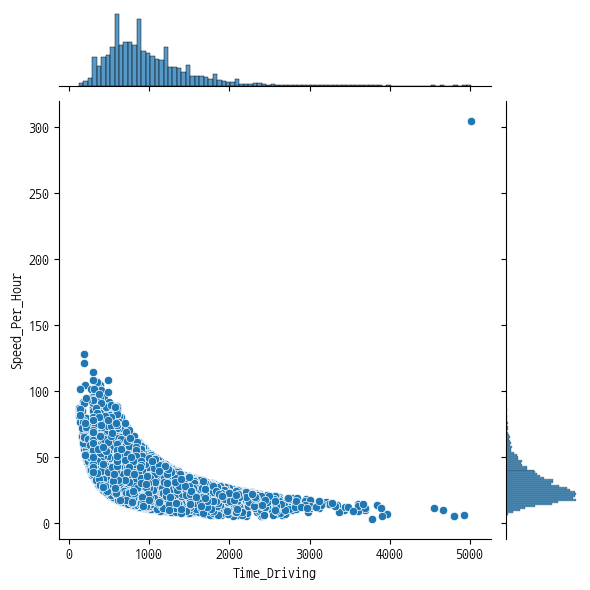

In [ ]:
# 여기에 답안코드를 작성하세요.
import seaborn as sns

sns.jointplot(data=df, x='Time_Driving', y='Speed_Per_Hour')

<br>
<br>

### **6. 위의 jointplot 그래프에서 시속 300이 넘는 이상치를 발견할 수 있습니다.**
### **가이드에 따라서 전처리를 수행하고 저장하세요.**
* **
- 대상 데이터프레임 : df
- jointplot 그래프를 보고 시속 300 초과하는 이상치를 찾아 해당 행(Row)을 삭제하세요.
- 불필요한 'RID' 컬럼을 삭제 하세요.
- 전처리 반영 후에 데이터프레임 변수명 df_temp 에 저장하세요.
---

In [ ]:
# 여기에 답안코드를 작성하세요.
df_temp = df[df.Speed_Per_Hour < 300]
df_temp.drop('RID', axis=1, inplace=True)
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9996 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Time_Departure  9996 non-null   object 
 1   Time_Arrival    9996 non-null   object 
 2   Distance        9994 non-null   float64
 3   Time_Driving    9996 non-null   float64
 4   Speed_Per_Hour  9996 non-null   float64
 5   Address1        9996 non-null   object 
 6   Address2        9996 non-null   object 
 7   Weekday         9996 non-null   int64  
 8   Hour            9996 non-null   int64  
 9   Day             9996 non-null   int64  
 10  Signaltype      9996 non-null   float64
dtypes: float64(4), int64(3), object(4)
memory usage: 937.1+ KB


/tmp/ipython-input-3403345932.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp.drop('RID', axis=1, inplace=True)


<br>
<br>

<br>
<br>

### **7. 모델링 성능을 제대로 얻기 위해서 결측치 처리는 필수입니다.**
### **아래 가이드를 따라 결측치 처리하세요.**
* **
- 대상 데이터프레임 : df_temp
- 각 컬럼의 결측치 개수를 확인하는 코드를 작성하세요.
- 결측치가 있는 행(row)를 삭제 하세요.
- 전처리 반영된 결과를 데이터프레임 변수명 df_na 에 저장하세요.
- 결측치 개수를 '답안07' 변수에 저장하세요.(예. 답안07 = 5)
---

In [ ]:
# 여기에 답안코드를 작성하세요.
df_temp.isnull().sum()
df_na = df_temp.dropna()
df_na.isnull().sum()
답안07 = 2

<br>
<br>

<br>
<br>

### **8. 모델링 성능을 제대로 얻기 위해서 불필요한 변수는 삭제해야 합니다.**
### **아래 가이드를 따라 불필요 데이터를 삭제 처리하세요.**
* **
- 대상 데이터프레임 : df_na
- 'Time_Departure', 'Time_Arrival' 2개 컬럼을 삭제하세요.
- 전처리 반영된 결과를 새로운 데이터프레임 변수명 df_del 에 저장하세요.
---

In [ ]:
# 여기에 답안코드를 작성하세요.
df_del = df_na.drop( ['Time_Departure', 'Time_Arrival'] , axis=1)
df_del

,Distance,Time_Driving,Speed_Per_Hour,Address1,Address2,Weekday,Hour,Day,Signaltype
0,3246.0,762.653992,15.322283,경기도,평택시,0,19,27,11.0
1,3858.0,796.081970,17.446445,경기도,의정부시,4,12,24,17.0
2,4125.0,1112.468018,13.348698,경기도,광명시,0,19,27,24.0
3,3748.0,651.973022,20.695335,경기도,안산시 상록구,0,11,20,19.0
4,3153.0,597.419006,18.999730,경기도,성남시 중원구,2,15,29,14.0
...,...,...,...,...,...,...,...,...,...
9995,10807.0,774.018982,50.263884,경기도,평택시,3,5,23,4.0
9996,6270.0,1511.703003,14.931504,서울특별시,서초구,1,16,28,17.0
9997,10484.0,890.312988,42.392283,경기도,안산시 단원구,1,8,21,21.0
9998,6529.0,300.302002,78.269208,경기도,성남시 분당구,4,6,24,10.0


<br>
<br>

### **9. 원-핫 인코딩(One-hot encoding)은 범주형 변수를 1과 0의 이진형 벡터로 변환하기 위하여 사용하는 방법입니다.**
### **원-핫 인코딩으로 아래 조건에 해당하는 컬럼 데이터를 변환하세요.**
* **
- 대상 데이터프레임 : df_del
- 원-핫 인코딩 대상 : object 타입의 전체 컬럼
- 활용 함수: Pandas의 get_dummies
- 해당 전처리가 반영된 결과를 데이터프레임 변수 df_preset에 저장해 주세요.
---

In [ ]:
# 여기에 답안코드를 작성하세요.
df_preset = pd.get_dummies(data=df_del, columns=['Address1', 'Address2'] )
df_preset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9994 entries, 0 to 9999
Data columns (total 81 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Distance           9994 non-null   float64
 1   Time_Driving       9994 non-null   float64
 2   Speed_Per_Hour     9994 non-null   float64
 3   Weekday            9994 non-null   int64  
 4   Hour               9994 non-null   int64  
 5   Day                9994 non-null   int64  
 6   Signaltype         9994 non-null   float64
 7   Address1_경기도       9994 non-null   bool   
 8   Address1_서울특별시     9994 non-null   bool   
 9   Address1_인천광역시     9994 non-null   bool   
 10  Address2_가평군       9994 non-null   bool   
 11  Address2_강남구       9994 non-null   bool   
 12  Address2_강동구       9994 non-null   bool   
 13  Address2_강북구       9994 non-null   bool   
 14  Address2_강서구       9994 non-null   bool   
 15  Address2_계양구       9994 non-null   bool   
 16  Address2_고양시 덕양구   9994 non-n

<br>
<br>

### **10. 훈련과 검증 각각에 사용할 데이터셋을 분리하려고 합니다.**
### **Time_Driving(실주행시간) 컬럼을 label값 y로, 나머지 컬럼을 feature값 X로 할당한 후 훈련데이터셋과 검증데이터셋으로 분리하세요(대소문자 유의).**
### **추가로,  가이드 따라서 훈련데이터셋과 검증데이터셋에 스케일링을 수행하세요.**
* **
- 대상 데이터프레임 : df_preset
- 훈련과 검증 데이터셋 분리
  - 훈련 데이터셋 label : y_train, 훈련 데이터셋 Feature: X_train
  - 검증 데이터셋 label : y_valid, 검증 데이터셋 Feature: X_valid
  - 훈련 데이터셋과 검증데이터셋 비율은 80:20
  - random_state : 42
  - Scikit-learn의 train_test_split 함수를 활용하세요.
- RobustScaler 스케일링 수행
  - sklearn.preprocessing의 RobustScaler 함수 사용
  - 훈련데이터셋의 Feature는 RobustScaler의 fit_transform 함수를 활용하여 X_train 변수로 할당
  - 검증데이터셋의 Feature는 RobustScaler의 transform 함수를 활용하여 X_valid 변수로 할당
---


In [ ]:
# 여기에 답안코드를 작성하세요.

X = df_preset.drop('Time_Driving', axis=1).values
y = df_preset['Time_Driving'].values

print('X, y shape : ', X.shape, y.shape)

from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)

from sklearn.preprocessing import RobustScaler
rs = RobustScaler()
X_train = rs.fit_transform(X_train)
X_valid = rs.transform(X_valid)


X, y shape :  (9994, 80) (9994,)
(7995, 80) (1999, 80) (7995,) (1999,)


<br>
<br>

###  **11. Time_Driving(실주행시간)을 예측하는 머신러닝 모델을 만들려고 합니다.**
###  **의사결정나무(decision tree)와 랜덤포레스트(RandomForest)는 여러 가지 규칙을 순차적으로 적용하면서**
### **독립 변수 공간을 분할하는 모형으로 분류(classification)와 회귀 분석(regression)에 모두 사용될 수 있습니다.**
###  **아래 가이드에 따라 의사결정나무(decision tree)와 랜덤포레스트(RandomForest) 모델 만들고 학습을 진행하세요.**

* **
- 의사결정나무(decision tree)
  - 트리의 최대 깊이 : 5로 설정
  - 노드를 분할하기 위한 최소한의 샘플 데이터수(min_samples_split) : 3로 설정
  - random_state : 120로 설정
  - 의사결정나무(decision tree) 모델을 dt 변수에 저장해 주세요.
- 랜덤포레스트(RandomForest)
  - 트리의 최대 깊이 : 5로 설정
  - 노드를 분할하기 위한 최소한의 샘플 데이터수(min_samples_split) : 3로 설정
  - random_state : 120로 설정
  - 랜덤포레스트(RandomForest) 모델을 rf 변수에 저장해 주세요.
- 위의 2개의 모델에 대해 fit을 활용해 모델을 학습해 주세요. 학습 시 훈련데이터 셋을 활용해 주세요.
---

In [ ]:
# 여기에 답안코드를 작성하세요.
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

dt = DecisionTreeRegressor(max_depth=5,   min_samples_split=3, random_state=120)
dt.fit(X_train, y_train)

rf = RandomForestRegressor(max_depth=5,   min_samples_split=3, random_state=120)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, min_samples_split=3, random_state=120)

<br>
<br>

### **12. 위 의사결정나무(decision tree)와 랜덤포레스트(RandomForest) 모델의 성능을 평가하려고 합니다.**
### **아래 가이드에 따라 예측 결과의 mae(Mean Absolute Error)를 구하고 평가하세요.**
* **
- 성능 평가는 검증 데이터셋을 활용하세요.
- 11번 문제에서 만든 의사결정나무(decision tree) 모델로 y값을 예측(predict)하여 y_pred_dt에 저장하세요.
- 검증 정답(y_valid)과 예측값(y_pred_dt)의 mae(Mean Absolute Error)를 구하고 dt_mae 변수에 저장하세요.
- 11번 문제에서 만든 랜덤포레스트(RandomForest) 모델로 y값을 예측(predict)하여 y_pred_rf에 저장하세요.
- 검증 정답(y_valid)과 예측값(y_pred_rf)의 mae(Mean Absolute Error)를 구하고 rf_mae 변수에 저장하세요.
- 2개의 모델에 대한 mae 성능평가 결과을 확인하여 성능좋은 모델 이름을 '답안12' 변수에 저장하세요.
  - 예) 답안12 = 'decisiontree' 혹은 답안12 = 'randomforest'
---

In [ ]:
# 여기에 답안코드를 작성하세요.

y_pred_dt = dt.predict(X_valid)
y_pred_rf = rf.predict(X_valid)

from sklearn.metrics import mean_absolute_error

dt_mae = mean_absolute_error(y_valid, y_pred_dt)
rf_mae = mean_absolute_error(y_valid, y_pred_rf)
print(dt_mae, rf_mae)

답안12 = 'randomforest'

108.66520360619405 66.49139503623555


<br>
<br>

> **<span style="color:red">다음 문항을 풀기 전에 </span>아래 코드를 실행하세요.**
>

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(1)

<br>
<br>

### **13. Time_Driving(실주행시간)을 예측하는 딥러닝 모델을 만들려고 합니다.**
### **아래 토폴로지 그림과 가이드에 따라 모델링하고 학습을 진행하는 코드를 작성하세요.**
* **
- Tensorflow framework를 사용하고 하단의 토폴로지 그림과 동일한 딥러닝 모델을 구현하세요.
- 히든 레이어의 activation 함수는 'selu'를 사용하고 , 마지막 아웃풋 레이어의 activation 함수는 'linear'를 사용하세요.
- EarlyStopping 콜백으로 9번 epoch 동안 모니터링 지표(val_loss)가 향상되지 않을 때 훈련을 중지하도록 설정하고 estop 변수에 저장하세요.
- optimizer는 adam, metrics는 mse, loss는 mean_squared_error로 설정하여 모델 컴파일을 설정하세요.
- 다음 조건에 따라 모델을 학습하고 학습정보는 history 변수에 저장해 주세요.
  - batch_size : 128
  - epoch : 50
- 안내된 내용 외 별도의 파라미터를 입력하지 마시기 바랍니다.
---


<img src="https://raw.githubusercontent.com/tessyoun/KT_AIVLESCHOOL_DATA/refs/heads/main/sample_dnn_v3.png">

In [ ]:
# 여기에 답안코드를 작성하세요

model = Sequential()
model.add(Dense(64, activation='selu', input_dim=X.shape[1]))
model.add(Dropout(0.1))
model.add(Dense(32, activation='selu'))
model.add(Dense(16, activation='selu'))
model.add(Dense(1, activation='linear'))

estop = EarlyStopping(monitor='val_loss', patience=9)
model.compile(optimizer='adam', loss='mean_squared_error', metrics = ['mse'])

history = model.fit(X_train, y_train, batch_size=128, epochs=50, validation_data=(X_valid, y_valid), callbacks=[estop])


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1168445.5000 - mse: 1168445.5000 - val_loss: 1082768.1250 - val_mse: 1082768.1250
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1089642.8750 - mse: 1089642.8750 - val_loss: 841055.4375 - val_mse: 841055.4375
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 749857.8125 - mse: 749857.8125 - val_loss: 306205.7188 - val_mse: 306205.7188
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 243410.6719 - mse: 243410.6719 - val_loss: 122668.8828 - val_mse: 122668.8828
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 127330.1406 - mse: 127330.1406 - val_loss: 93958.4297 - val_mse: 93958.4297
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 101707.2812 - mse: 101707.2812 - val_loss: 73270.8281 - val_mse: 73270.8281
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 81158.6953 - mse: 81158.6953 - val_loss: 58599.2148 - val_mse: 58599.2148
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 672

<br>
<br>

### **14. 위 딥러닝 모델의 성능을 평가하려고 합니다.**
### **Matplotlib 라이브러리 활용해서 학습 mse와 검증 mse를 그래프로 표시하세요.**
* **
- 1개의 그래프에 학습 mse과 검증 mse 2가지를 모두 표시하세요.
- 위 2가지 각각의 범례를 'mse', 'val_mse'로 표시하세요.
- 그래프의 타이틀은 'Model MSE'로 표시하세요.
- X축에는 'Epochs'라고 표시하고 Y축에는 'MSE'라고 표시하세요.
---


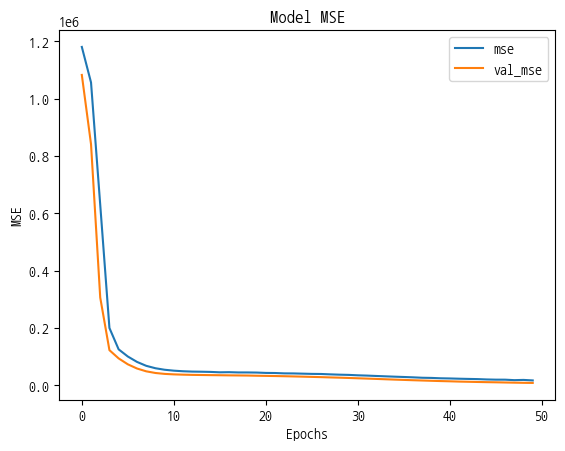

In [ ]:
# 여기에 답안코드를 작성하세요.
plt.plot(history.history["mse"])
plt.plot(history.history["val_mse"])
plt.title("Model MSE")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend(['mse', 'val_mse'])
plt.show()

<br>
<br>

### **1번부터 14번까지 모든 문제를 풀었습니다. 수고하셨습니다.**
### **'최종제출 및 종료'를 클릭하셔서 답안을 제출해 주시기 바랍니다.**